# Fruits and Vegetables Image Classifier
**Course:** Advanced Machine Learning — Final Project

**University:** Parami University

**Professor:** Dr. Nwe Nwe Htay Win

**Student:** Kyaw Toe Toe Han

**Datae:** 25.05.2026

## Imports & Setup


In [2]:
# Imports libraries and setup
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.utils import image_dataset_from_directory

# Set exact dataset directory paths
base_dir = r"D:\Parami University\Advanced ML\Final Project\FruitsAndVegetablesClassifier"
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')
val_dir = os.path.join(base_dir, 'validation')

## Data Sanitization

I will scan every image in the train and validation directories and removes any file that TensorFlow cannot decode.


In [3]:
# Data sanitization
def clean_images(directory):
    removed_count = 0
    for folder in os.listdir(directory):
        folder_path = os.path.join(directory, folder)

        if not os.path.isdir(folder_path):
            continue

        for file in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file)
            try:
                # Test if image is readable
                img_file = tf.io.read_file(file_path)
                tf.image.decode_image(img_file)
            except Exception:
                # Delete broken image
                os.remove(file_path)
                removed_count += 1

    print(f"Cleaned {directory}. Removed {removed_count} broken files.")

# Clean training and validation data
clean_images(train_dir)
clean_images(val_dir)

Cleaned D:\Parami University\Advanced ML\Final Project\FruitsAndVegetablesClassifier\train. Removed 0 broken files.
Cleaned D:\Parami University\Advanced ML\Final Project\FruitsAndVegetablesClassifier\validation. Removed 0 broken files.


## Dataset Loading & Preprocessing

In [4]:
# Dataset generation
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

# Load training data
train_dataset = image_dataset_from_directory(
    train_dir,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

# Load validation data
val_dataset = image_dataset_from_directory(
    val_dir,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

# Load test data
test_dataset = image_dataset_from_directory(
    test_dir,
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

# Store class names and count
class_names = train_dataset.class_names
num_classes = len(class_names)

Found 3115 files belonging to 36 classes.
Found 351 files belonging to 36 classes.
Found 359 files belonging to 36 classes.


### Confirm Loaded Classes

In [5]:
print('Class names:', class_names)
print('Total number of classes:', num_classes)

Class names: ['apple', 'banana', 'beetroot', 'bell pepper', 'cabbage', 'capsicum', 'carrot', 'cauliflower', 'chilli pepper', 'corn', 'cucumber', 'eggplant', 'garlic', 'ginger', 'grapes', 'jalepeno', 'kiwi', 'lemon', 'lettuce', 'mango', 'onion', 'orange', 'paprika', 'pear', 'peas', 'pineapple', 'pomegranate', 'potato', 'raddish', 'soy beans', 'spinach', 'sweetcorn', 'sweetpotato', 'tomato', 'turnip', 'watermelon']
Total number of classes: 36


## Dataset Exploration

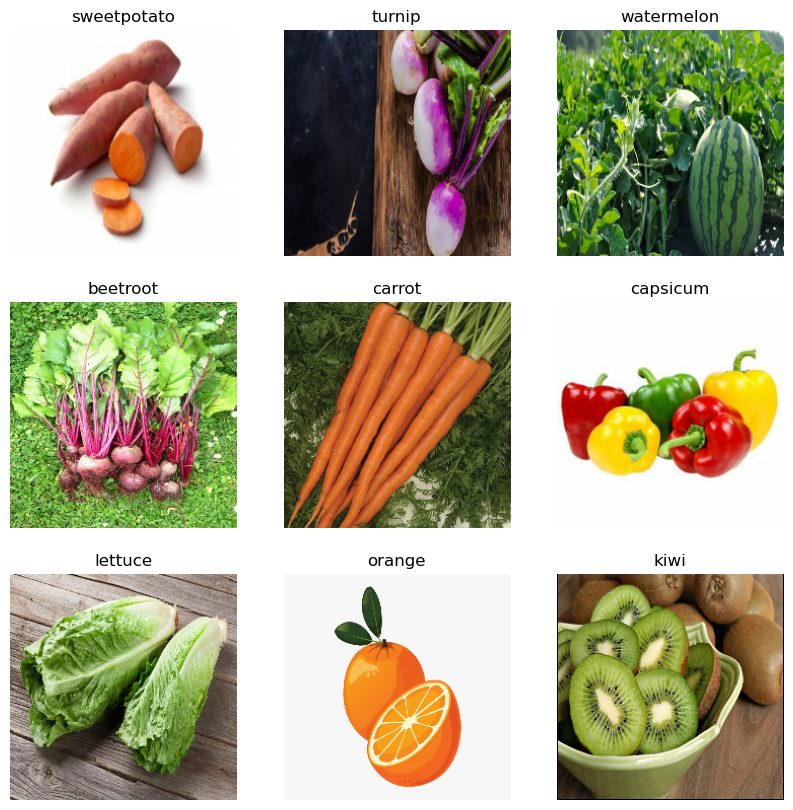

In [6]:
# Visualize sample images from the training set
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [7]:
# Inspect batch dimensions
for image_batch, labels_batch in train_dataset:
    print('Image batch shape:', image_batch.shape)
    print('Labels batch shape:', labels_batch.shape)
    break

Image batch shape: (32, 224, 224, 3)
Labels batch shape: (32,)


## Pipeline

In [8]:
# Pipeline optimization
AUTOTUNE = tf.data.AUTOTUNE

# Cache data for faster training
train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

## Model Architecture

In [9]:
# Model architecture
# Build convolutional neural network
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes)
])

c:\Users\Liam Kyaw\miniconda3\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
# Print model summary to verify architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 36)             │         4,644 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,943,076 (49.37 MB)

 Trainable params: 12,943,076 (49.37 MB)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [11]:
# Training
# Compile the model
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Train the model
epochs = 10
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs
)

Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 54s 536ms/step - accuracy: 0.0520 - loss: 3.6275 - val_accuracy: 0.1282 - val_loss: 3.1299
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 44s 450ms/step - accuracy: 0.1316 - loss: 3.0553 - val_accuracy: 0.3419 - val_loss: 2.2643
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 43s 439ms/step - accuracy: 0.2703 - loss: 2.5013 - val_accuracy: 0.5214 - val_loss: 1.6402
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 43s 441ms/step - accuracy: 0.4398 - loss: 1.9393 - val_accuracy: 0.7037 - val_loss: 1.0816
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 43s 439ms/step - accuracy: 0.5955 - loss: 1.4029 - val_accuracy: 0.8063 - val_loss: 0.7881
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 43s 439ms/step - accuracy: 0.7451 - loss: 0.9001 - val_accuracy: 0.8063 - val_loss: 0.6775
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 45s 457ms/step - accuracy: 0.8222 - loss: 0.5899 - val_accuracy: 0.8519 - val_loss: 0.5047
Epoch 8/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 46s 465ms/step - accuracy: 0.8613 - loss: 0.4665 - val_accu

## Visualization & Evaluation

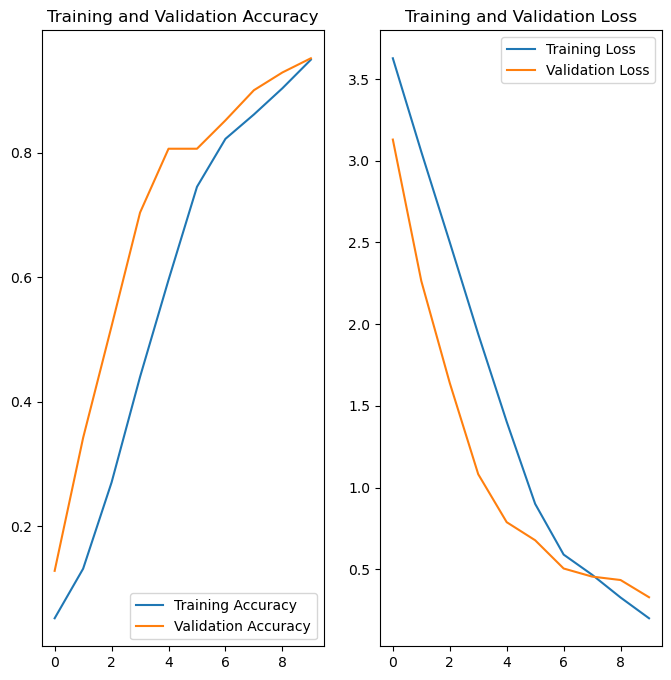

12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 332ms/step - accuracy: 0.9526 - loss: 0.3246
Final Test Accuracy: 95.26%


In [12]:
# Visualization and evaluation
# Get metrics from history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(epochs)

# Set up graph layout
plt.figure(figsize=(8, 8))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

# Show graphs
plt.show()

# Test final accuracy on unseen data
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Final Test Accuracy: {test_acc * 100:.2f}%")

In [13]:
# Save the model for deployment
model.save('fruits_veg_model.keras') # or .h5